# What Makes a Movie Successful? — Predictive Modeling of Film Ratings

**Objective:** Identify the features that best predict a movie's audience satisfaction (TMDb rating) and build a predictive model, including a forecast for Christopher Nolan's *The Odyssey* (2026).

**Dataset:** 18,612 movies (2020–2025) from TMDb + Wikipedia, with budget, revenue, genres, runtime, popularity, cast/crew, keywords, and production metadata.

**Models:** Ridge Regression, Random Forest, Gradient Boosting, XGBoost

---


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — will skip. Install with: pip install xgboost")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Data Loading & Overview


In [12]:
df_raw = pd.read_csv('final_merged.csv')
print(f"Raw dataset: {df_raw.shape[0]:,} movies, {df_raw.shape[1]} columns")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nKey numeric stats:")
print(df_raw[['vote_count', 'vote_average', 'revenue', 'runtime', 'budget', 'popularity']].describe().round(2))


Raw dataset: 18,612 movies, 27 columns

Columns: ['id', 'title_tmdb', 'vote_count', 'vote_average', 'release_date', 'revenue', 'runtime', 'budget', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'keywords', 'production_companies', 'production_countries', 'spoken_languages', 'year', 'title_c', 'title_wiki', 'url', 'director', 'year_tmdb', 'title_c_tmdb', 'matched_title', 'year_wiki', 'title_c_wiki']

Key numeric stats:
       vote_count  vote_average       revenue   runtime        budget  \
count    18612.00      18612.00  1.861200e+04  18612.00  1.861200e+04   
mean        78.40          3.36  3.352228e+06     68.30  1.655669e+06   
std        484.35          3.47  4.404518e+07     52.93  1.566303e+07   
min          0.00          0.00  0.000000e+00      0.00  0.000000e+00   
25%          0.00          0.00  0.000000e+00     11.00  0.000000e+00   
50%          1.00          2.50  0.000000e+00     86.00  0.000000e+00   
75%          8.00          6.60  0.000000e+00   

## 2. Data Cleaning & Feature Engineering

Key steps:
- Filter to movies with meaningful vote counts (≥50 votes) for reliable ratings
- Parse release dates into temporal features (month, quarter, day of week)
- Encode genre flags
- Create financial features (budget tiers, log transforms)
- Compute director track records from the dataset
- Engineer language and production features


In [13]:
# ---- FILTER: Reliable ratings only ----
df = df_raw[df_raw['vote_count'] >= 50].copy()
print(f"Movies with ≥50 votes: {len(df):,} (dropped {len(df_raw) - len(df):,} low-vote films)")

# ---- PARSE DATES ----
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month
df['release_quarter'] = df['release_date'].dt.quarter
df['release_dayofweek'] = df['release_date'].dt.dayofweek  # 0=Monday
df['release_year'] = df['release_date'].dt.year
df['is_summer'] = df['release_month'].isin([5, 6, 7, 8]).astype(int)
df['is_holiday'] = df['release_month'].isin([11, 12]).astype(int)
df['is_friday_release'] = (df['release_dayofweek'] == 4).astype(int)

# ---- GENRE ENCODING ----
all_genres = set()
for g in df['genres'].dropna():
    for genre in g.split(', '):
        all_genres.add(genre.strip())
all_genres = sorted(all_genres)

for genre in all_genres:
    df[f'genre_{genre}'] = df['genres'].apply(
        lambda x: 1 if pd.notna(x) and genre in str(x) else 0
    )
df['num_genres'] = df['genres'].apply(
    lambda x: len(str(x).split(', ')) if pd.notna(x) else 0
)

print(f"Genres encoded: {all_genres}")

# ---- FINANCIAL FEATURES ----
df['has_budget'] = (df['budget'] > 0).astype(int)
df['has_revenue'] = (df['revenue'] > 0).astype(int)
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_vote_count'] = np.log1p(df['vote_count'])

# Budget tiers
df['budget_tier'] = pd.cut(df['budget'], 
                           bins=[-1, 0, 1_000_000, 15_000_000, 50_000_000, 100_000_000, 1_000_000_000],
                           labels=[0, 1, 2, 3, 4, 5]).astype(float).fillna(0)

# ROI (for movies with both budget and revenue)
mask_roi = (df['budget'] > 0) & (df['revenue'] > 0)
df['roi'] = np.nan
df.loc[mask_roi, 'roi'] = df.loc[mask_roi, 'revenue'] / df.loc[mask_roi, 'budget']

# ---- RUNTIME CLEANING ----
df.loc[df['runtime'] <= 0, 'runtime'] = np.nan
df.loc[df['runtime'] > 300, 'runtime'] = np.nan
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

# ---- LANGUAGE FEATURES ----
df['is_english'] = (df['original_language'] == 'en').astype(int)

# ---- ADULT FLAG ----
df['is_adult'] = df['adult'].astype(int)

# ---- DIRECTOR TRACK RECORD ----
# Compute each director's average rating from OTHER movies in the dataset (leave-one-out style)
director_stats = df.groupby('director').agg(
    dir_movie_count=('vote_average', 'count'),
    dir_total_rating=('vote_average', 'sum'),
    dir_avg_rating_raw=('vote_average', 'mean'),
    dir_max_rating=('vote_average', 'max'),
    dir_avg_votes=('vote_count', 'mean'),
).reset_index()

df = df.merge(director_stats, on='director', how='left')

# Leave-one-out: director avg excluding current movie
df['dir_avg_rating'] = np.where(
    df['dir_movie_count'] > 1,
    (df['dir_total_rating'] - df['vote_average']) / (df['dir_movie_count'] - 1),
    df['dir_avg_rating_raw']  # fallback for single-movie directors
)
df['dir_experienced'] = (df['dir_movie_count'] >= 3).astype(int)

# ---- KEYWORD COUNT ----
df['num_keywords'] = df['keywords'].apply(
    lambda x: len(str(x).split(', ')) if pd.notna(x) else 0
)

# ---- PRODUCTION COMPANY COUNT ----
df['num_prod_companies'] = df['production_companies'].apply(
    lambda x: len(str(x).split(', ')) if pd.notna(x) else 0
)

# Major studio flag (simplified)
major_studios = ['Warner Bros', 'Universal', 'Disney', 'Paramount', 'Columbia', 
                 'Marvel', '20th Century', 'Lionsgate', 'Sony', 'New Line']
df['is_major_studio'] = df['production_companies'].apply(
    lambda x: 1 if pd.notna(x) and any(s.lower() in str(x).lower() for s in major_studios) else 0
)

print(f"\nFinal cleaned dataset: {len(df):,} movies")
print(f"Target (vote_average) stats:")
print(df['vote_average'].describe().round(3))


Movies with ≥50 votes: 2,336 (dropped 16,276 low-vote films)
Genres encoded: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

Final cleaned dataset: 2,336 movies
Target (vote_average) stats:
count    2336.000
mean        6.629
std         0.779
min         3.565
25%         6.100
50%         6.641
75%         7.186
max         9.154
Name: vote_average, dtype: float64


## 3. Exploratory Data Analysis

### 3.1 Rating Distribution


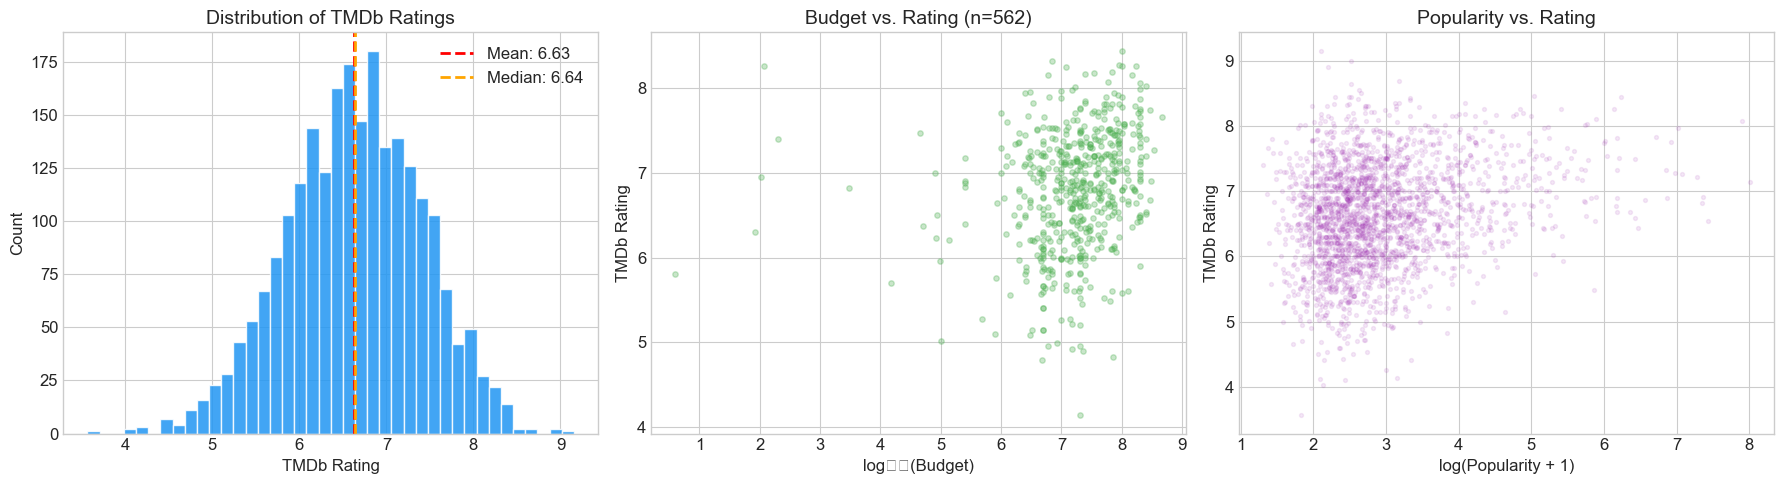

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution
axes[0].hist(df['vote_average'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(df['vote_average'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Mean: {df['vote_average'].mean():.2f}")
axes[0].axvline(df['vote_average'].median(), color='orange', linestyle='--', linewidth=2, 
                label=f"Median: {df['vote_average'].median():.2f}")
axes[0].set_xlabel('TMDb Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of TMDb Ratings')
axes[0].legend()

# Budget vs Rating (movies with budget > 0)
budget_mask = df['budget'] > 0
axes[1].scatter(np.log10(df.loc[budget_mask, 'budget']), 
                df.loc[budget_mask, 'vote_average'], alpha=0.3, s=15, color='#4CAF50')
axes[1].set_xlabel('log\u2081\u2080(Budget)')
axes[1].set_ylabel('TMDb Rating')
axes[1].set_title(f'Budget vs. Rating (n={budget_mask.sum():,})')

# Popularity vs Rating
axes[2].scatter(np.log1p(df['popularity']), df['vote_average'], alpha=0.1, s=8, color='#9C27B0')
axes[2].set_xlabel('log(Popularity + 1)')
axes[2].set_ylabel('TMDb Rating')
axes[2].set_title('Popularity vs. Rating')

plt.tight_layout()
plt.savefig('fig_rating_dist.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Genre Analysis


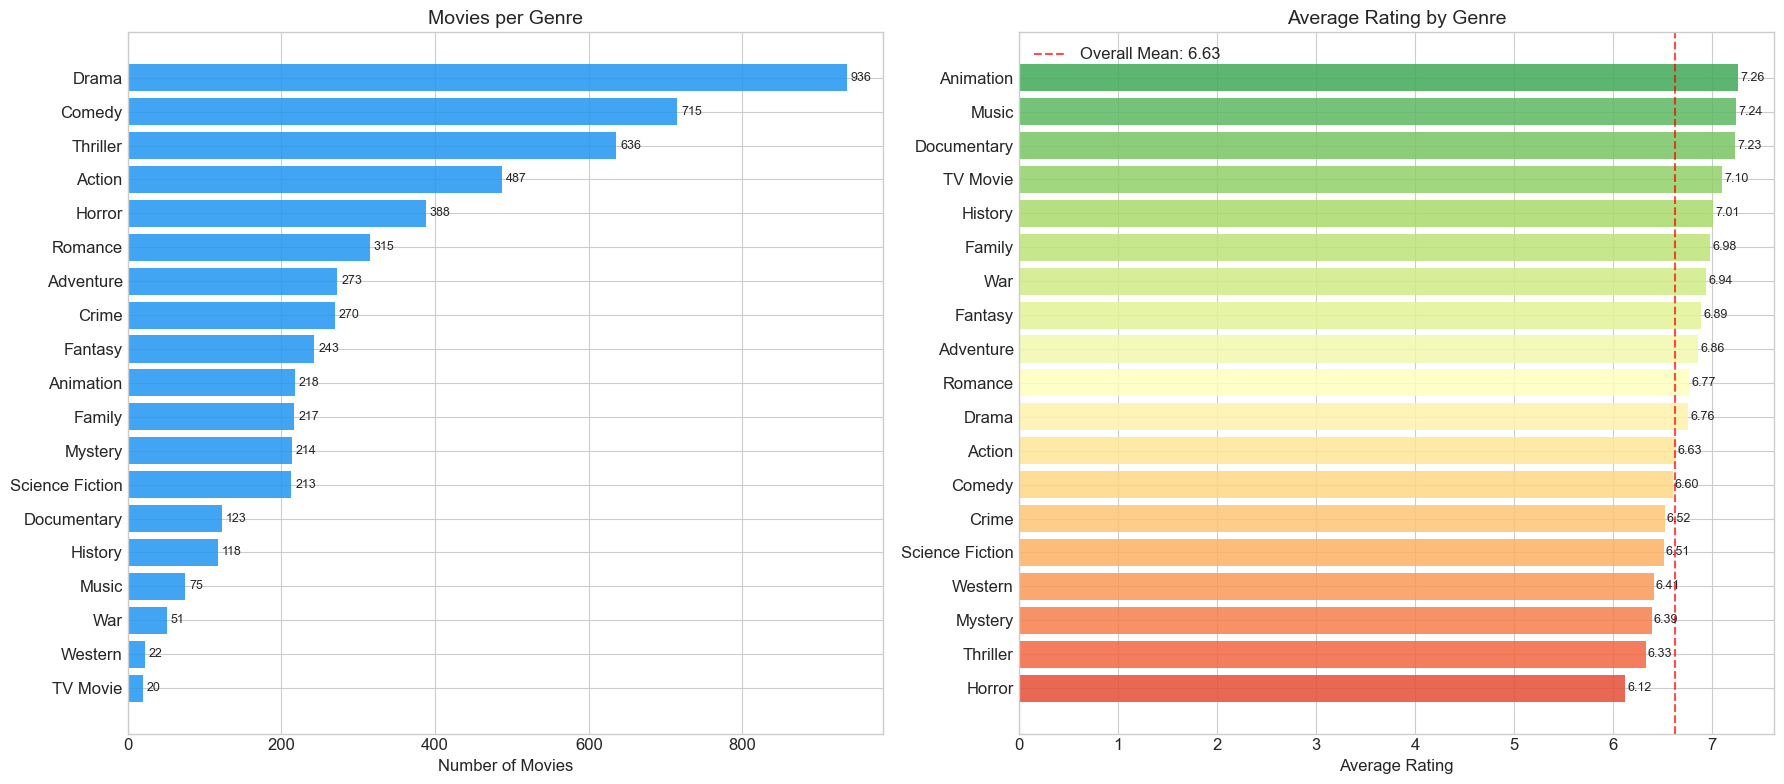

In [15]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]
genre_stats = []
for g in genre_cols:
    genre_name = g.replace('genre_', '')
    count = df[g].sum()
    if count >= 20:
        avg_rating = df.loc[df[g] == 1, 'vote_average'].mean()
        genre_stats.append({'Genre': genre_name, 'Count': int(count), 'Avg Rating': round(avg_rating, 2)})

genre_df = pd.DataFrame(genre_stats).sort_values('Avg Rating', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Counts
gs = genre_df.sort_values('Count', ascending=True)
axes[0].barh(gs['Genre'], gs['Count'], color='#2196F3', alpha=0.85)
axes[0].set_xlabel('Number of Movies')
axes[0].set_title('Movies per Genre')
for i, (_, row) in enumerate(gs.iterrows()):
    axes[0].text(row['Count'] + 5, i, f"{row['Count']:,}", va='center', fontsize=9)

# Avg ratings
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(genre_df)))
axes[1].barh(genre_df['Genre'], genre_df['Avg Rating'], color=colors, alpha=0.85)
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Average Rating by Genre')
axes[1].axvline(df['vote_average'].mean(), color='red', linestyle='--', alpha=0.7, 
                label=f"Overall Mean: {df['vote_average'].mean():.2f}")
axes[1].legend()
for i, (_, row) in enumerate(genre_df.iterrows()):
    axes[1].text(row['Avg Rating'] + 0.02, i, f"{row['Avg Rating']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Temporal & Financial Patterns


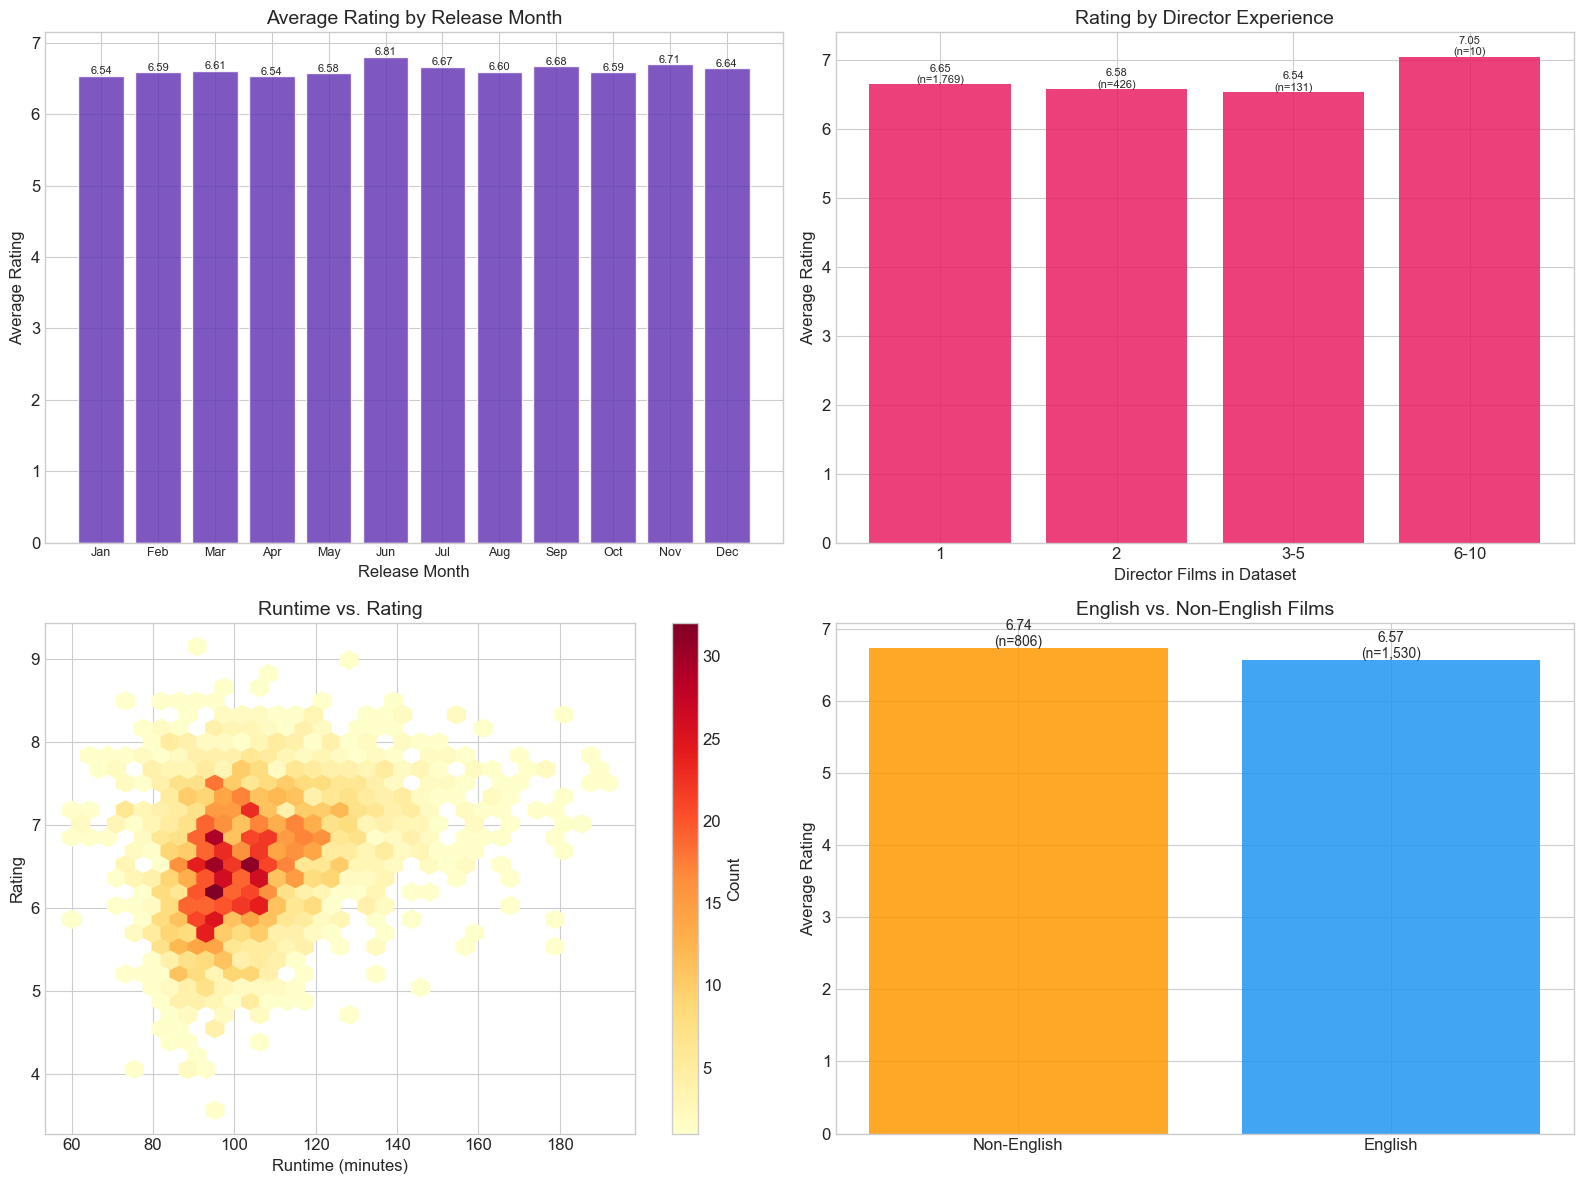

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Release month vs rating
month_stats = df.groupby('release_month')['vote_average'].agg(['mean', 'count']).reset_index()
bars = axes[0, 0].bar(month_stats['release_month'], month_stats['mean'], 
                       color='#673AB7', alpha=0.85, edgecolor='white')
axes[0, 0].set_xlabel('Release Month')
axes[0, 0].set_ylabel('Average Rating')
axes[0, 0].set_title('Average Rating by Release Month')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
for bar, (_, row) in zip(bars, month_stats.iterrows()):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{row['mean']:.2f}", ha='center', fontsize=8)

# Director experience vs rating
exp_bins = pd.cut(df['dir_movie_count'], bins=[0, 1, 2, 5, 10, 100], 
                  labels=['1', '2', '3-5', '6-10', '10+'])
exp_stats = df.groupby(exp_bins, observed=True)['vote_average'].agg(['mean', 'count']).reset_index()
exp_stats.columns = ['Experience', 'Mean', 'Count']
bars2 = axes[0, 1].bar(exp_stats['Experience'], exp_stats['Mean'], color='#E91E63', alpha=0.85)
axes[0, 1].set_xlabel('Director Films in Dataset')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_title('Rating by Director Experience')
for bar, (_, row) in zip(bars2, exp_stats.iterrows()):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{row['Mean']:.2f}\n(n={row['Count']:,})", ha='center', fontsize=8)

# Runtime vs rating
runtime_valid = df[df['runtime'].between(60, 240)]
axes[1, 0].hexbin(runtime_valid['runtime'], runtime_valid['vote_average'], gridsize=30,
                  cmap='YlOrRd', mincnt=1)
axes[1, 0].set_xlabel('Runtime (minutes)')
axes[1, 0].set_ylabel('Rating')
axes[1, 0].set_title('Runtime vs. Rating')
plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Count')

# English vs non-English
lang_stats = df.groupby('is_english')['vote_average'].agg(['mean', 'count']).reset_index()
lang_stats['label'] = lang_stats['is_english'].map({0: 'Non-English', 1: 'English'})
bars3 = axes[1, 1].bar(lang_stats['label'], lang_stats['mean'], 
                        color=['#FF9800', '#2196F3'], alpha=0.85)
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_title('English vs. Non-English Films')
for bar, (_, row) in zip(bars3, lang_stats.iterrows()):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{row['mean']:.2f}\n(n={row['count']:,})", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_temporal_financial.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Feature Correlations


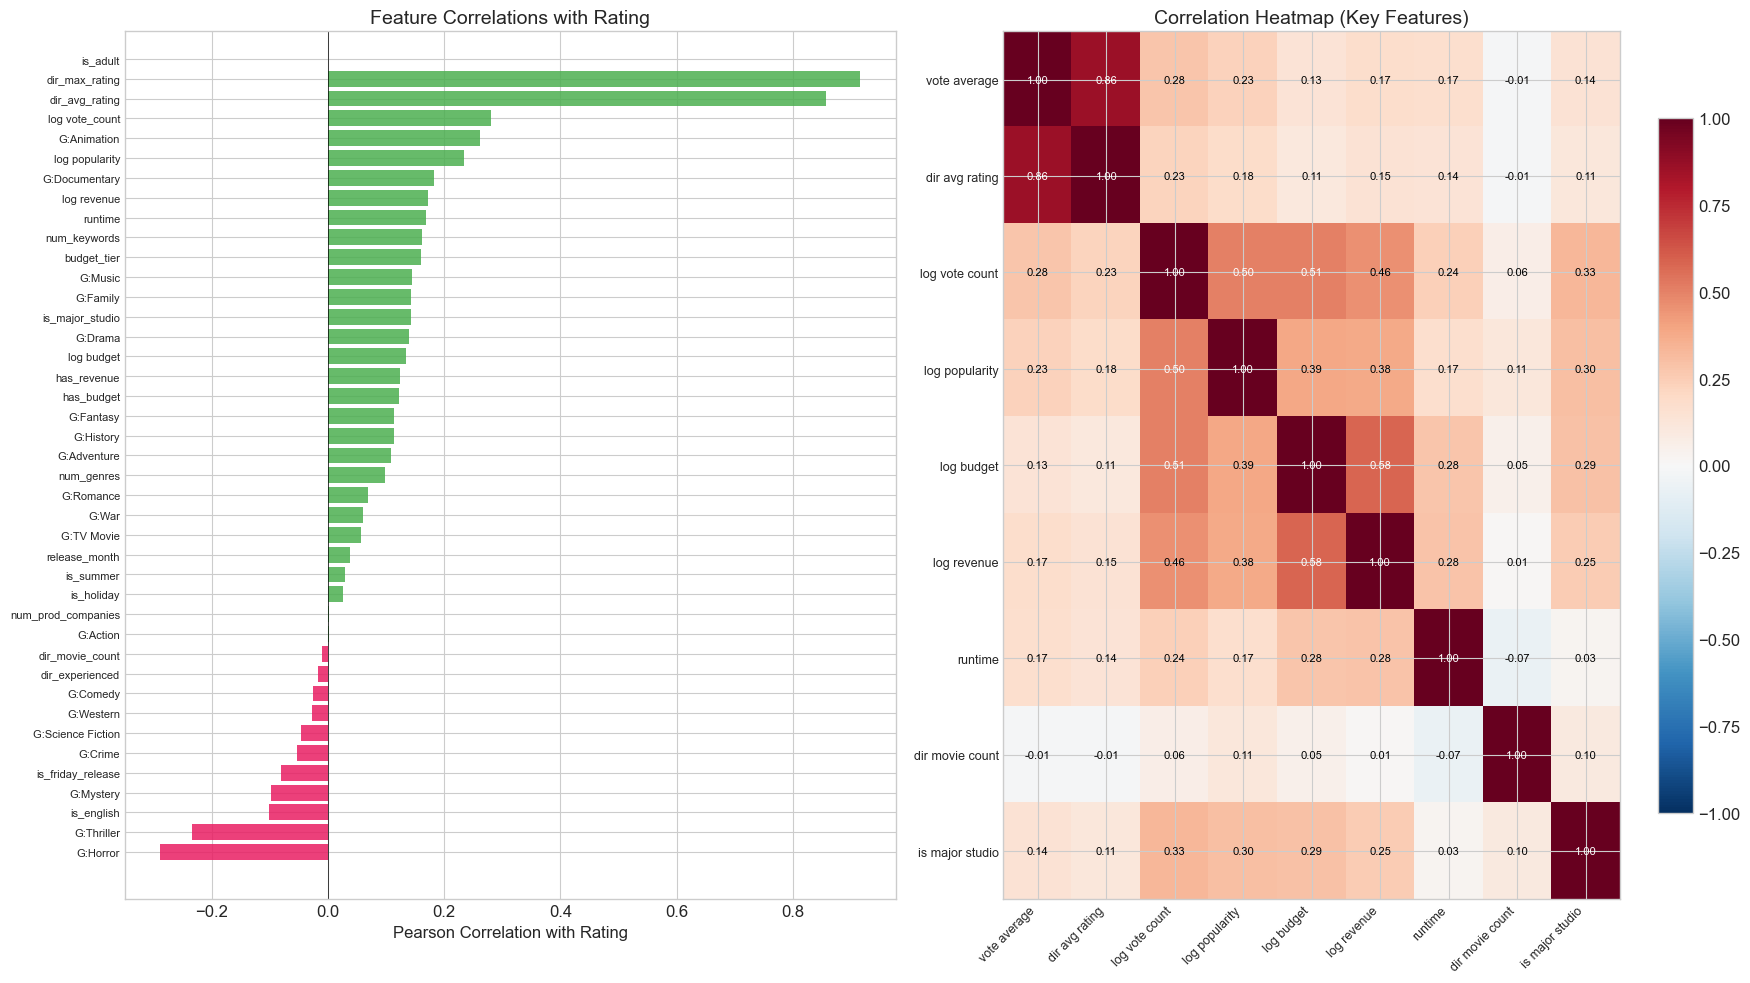

Top 10 features most correlated with rating:
dir_max_rating       0.9165
dir_avg_rating       0.8569
genre_Horror         0.2889
log_vote_count       0.2799
genre_Animation      0.2613
log_popularity       0.2336
genre_Thriller       0.2333
genre_Documentary    0.1825
log_revenue          0.1721
runtime              0.1682


In [17]:
# Select numeric features for correlation
numeric_features = [
    'runtime', 'log_budget', 'log_revenue', 'log_popularity', 'log_vote_count',
    'num_genres', 'is_english', 'is_adult', 'is_summer', 'is_holiday', 'is_friday_release',
    'has_budget', 'has_revenue', 'budget_tier', 'is_major_studio',
    'dir_avg_rating', 'dir_movie_count', 'dir_max_rating', 'dir_experienced',
    'num_keywords', 'num_prod_companies', 'release_month',
] + [c for c in df.columns if c.startswith('genre_') and df[c].sum() >= 20]

corr_with_target = df[numeric_features + ['vote_average']].corr()['vote_average'].drop('vote_average').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Correlation bar chart
colors = ['#E91E63' if v < 0 else '#4CAF50' for v in corr_with_target]
axes[0].barh(range(len(corr_with_target)), corr_with_target.values, color=colors, alpha=0.85)
axes[0].set_yticks(range(len(corr_with_target)))
axes[0].set_yticklabels([c.replace('genre_', 'G:').replace('log_', 'log ') for c in corr_with_target.index], fontsize=8)
axes[0].set_xlabel('Pearson Correlation with Rating')
axes[0].set_title('Feature Correlations with Rating')
axes[0].axvline(0, color='black', linewidth=0.5)

# Heatmap of top features
top_feats = ['vote_average', 'dir_avg_rating', 'log_vote_count', 'log_popularity',
             'log_budget', 'log_revenue', 'runtime', 'dir_movie_count', 'is_major_studio']
corr_matrix = df[top_feats].corr()
im = axes[1].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(top_feats)))
axes[1].set_yticks(range(len(top_feats)))
labels = [c.replace('log_', 'log ').replace('_', ' ') for c in top_feats]
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].set_title('Correlation Heatmap (Key Features)')
for i in range(len(top_feats)):
    for j in range(len(top_feats)):
        axes[1].text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8,
                    color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('fig_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features most correlated with rating:")
print(corr_with_target.abs().sort_values(ascending=False).head(10).round(4).to_string())


## 4. Feature Selection

We use **Random Forest importance** and **Pearson correlation** to rank features, then select the top predictors.


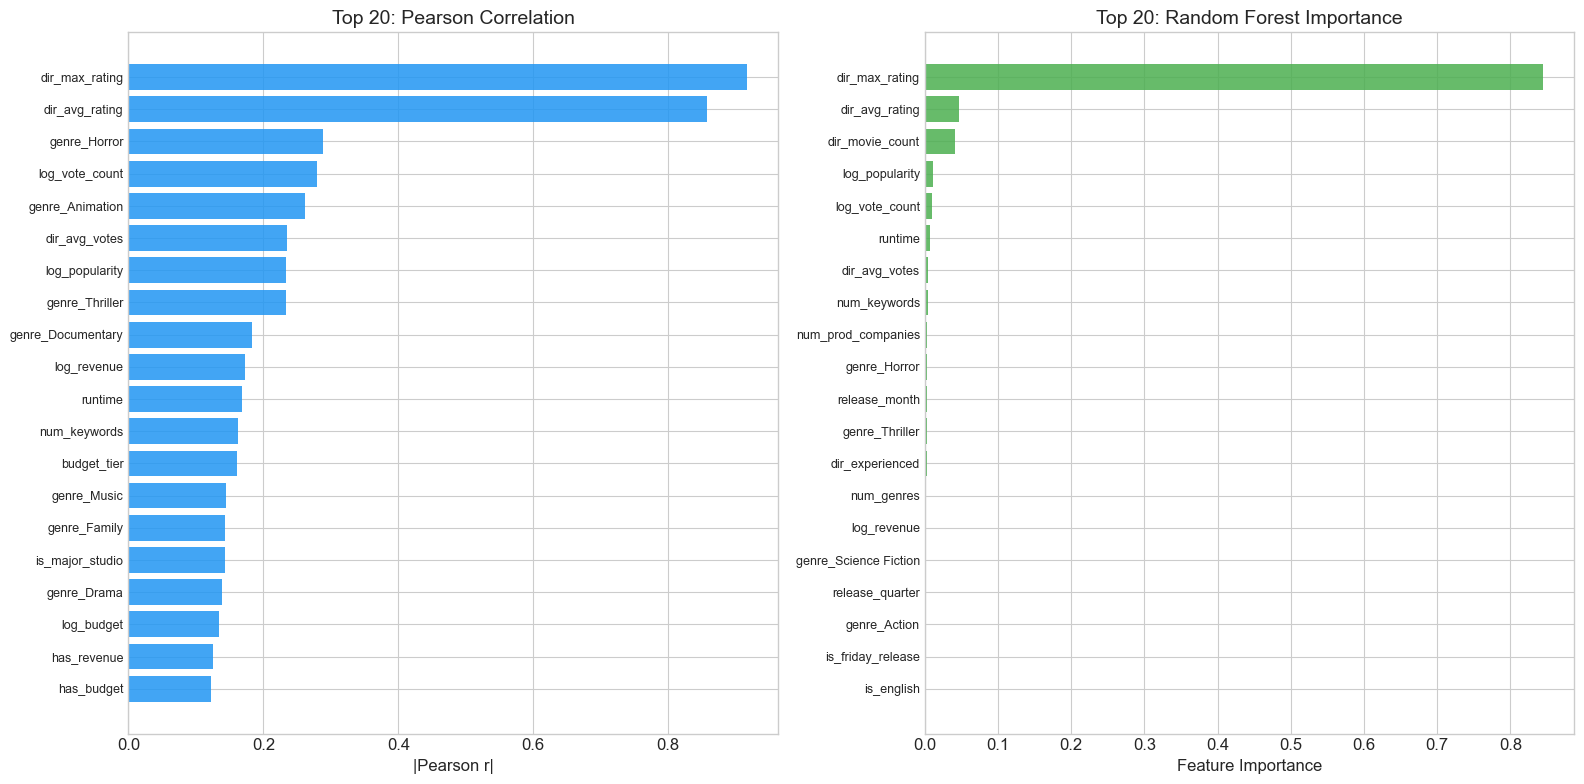

Selected 20 features for modeling:
   1. dir_max_rating                 (avg rank: 1.0)
   2. dir_avg_rating                 (avg rank: 2.0)
   3. log_vote_count                 (avg rank: 4.5)
   4. log_popularity                 (avg rank: 5.5)
   5. dir_avg_votes                  (avg rank: 6.5)
   6. genre_Horror                   (avg rank: 6.5)
   7. runtime                        (avg rank: 8.5)
   8. genre_Thriller                 (avg rank: 10.0)
   9. num_keywords                   (avg rank: 10.0)
  10. log_revenue                    (avg rank: 12.5)
  11. genre_Animation                (avg rank: 19.0)
  12. log_budget                     (avg rank: 19.5)
  13. num_genres                     (avg rank: 20.0)
  14. budget_tier                    (avg rank: 20.5)
  15. genre_Drama                    (avg rank: 21.5)
  16. dir_movie_count                (avg rank: 21.5)
  17. release_month                  (avg rank: 22.0)
  18. is_english                     (avg rank: 22.0)


In [18]:
from sklearn.feature_selection import mutual_info_regression

# All candidate features
all_features = [
    'runtime', 'log_budget', 'log_revenue', 'log_popularity', 'log_vote_count',
    'num_genres', 'is_english', 'is_adult', 'is_summer', 'is_holiday', 'is_friday_release',
    'has_budget', 'has_revenue', 'budget_tier', 'is_major_studio',
    'dir_avg_rating', 'dir_movie_count', 'dir_max_rating', 'dir_experienced',
    'dir_avg_votes',
    'num_keywords', 'num_prod_companies', 'release_month', 'release_quarter',
] + [c for c in df.columns if c.startswith('genre_') and df[c].sum() >= 20]

X_sel = df[all_features].copy()
y_sel = df['vote_average'].copy()

# Pearson correlation
pearson = X_sel.corrwith(y_sel).abs().sort_values(ascending=False)

# Random Forest importance
rf_sel = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_sel.fit(X_sel, y_sel)
rf_imp = pd.Series(rf_sel.feature_importances_, index=all_features).sort_values(ascending=False)

# Combined ranking
rankings = pd.DataFrame({'Pearson': pearson, 'RF_Importance': rf_imp})
rankings['Pearson_Rank'] = rankings['Pearson'].rank(ascending=False)
rankings['RF_Rank'] = rankings['RF_Importance'].rank(ascending=False)
rankings['Avg_Rank'] = rankings[['Pearson_Rank', 'RF_Rank']].mean(axis=1)
rankings = rankings.sort_values('Avg_Rank')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_n = 20
top_p = pearson.head(top_n)
axes[0].barh(range(top_n), top_p.values[::-1], color='#2196F3', alpha=0.85)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_p.index[::-1], fontsize=9)
axes[0].set_xlabel('|Pearson r|')
axes[0].set_title('Top 20: Pearson Correlation')

top_rf = rf_imp.head(top_n)
axes[1].barh(range(top_n), top_rf.values[::-1], color='#4CAF50', alpha=0.85)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_rf.index[::-1], fontsize=9)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Top 20: Random Forest Importance')

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Select top features
selected_features = rankings.head(20).index.tolist()
print(f"Selected {len(selected_features)} features for modeling:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f:30s} (avg rank: {rankings.loc[f, 'Avg_Rank']:.1f})")


## 5. Model Building — 4 Regression Models

1. **Ridge Regression** — L2-regularized linear model (baseline)
2. **Random Forest** — Ensemble of decision trees
3. **Gradient Boosting** — Sequential boosting ensemble
4. **XGBoost** — Optimized gradient boosting


In [19]:
# Prepare data
X = df[selected_features].copy()
y = df['vote_average'].copy()

# Stratified train/test split
y_bins = pd.cut(y, bins=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins
)

print(f"Training set: {X_train.shape[0]:,} movies")
print(f"Test set:     {X_test.shape[0]:,} movies")
print(f"Training mean: {y_train.mean():.3f}, Test mean: {y_test.mean():.3f}")

# Scale for Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set: 1,868 movies
Test set:     468 movies
Training mean: 6.632, Test mean: 6.615


In [20]:
# Define 4 models
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.8, random_state=42
    ),
}

if HAS_XGB:
    models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1, 
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )
else:
    print("XGBoost not available — using 3 models")

# Train and evaluate
results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    if name == 'Ridge Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results.append({
        'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
        'R\u00b2': round(r2, 4), 'CV RMSE': round(cv_rmse, 4)
    })
    trained_models[name] = (model, y_pred)
    print(f"  RMSE={rmse:.4f}, MAE={mae:.4f}, R\u00b2={r2:.4f}")

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# Identify best model
best_name = results_df.iloc[0]['Model']
best_model, best_preds = trained_models[best_name]
print(f"\nBest model: {best_name}")


Training Ridge Regression...
  RMSE=0.2385, MAE=0.1186, R²=0.9068
Training Random Forest...
  RMSE=0.2247, MAE=0.0835, R²=0.9173
Training Gradient Boosting...
  RMSE=0.2130, MAE=0.0882, R²=0.9257
Training XGBoost...
  RMSE=0.2108, MAE=0.0853, R²=0.9272

MODEL COMPARISON
            Model   RMSE    MAE     R²  CV RMSE
          XGBoost 0.2108 0.0853 0.9272   0.2286
Gradient Boosting 0.2130 0.0882 0.9257   0.2270
    Random Forest 0.2247 0.0835 0.9173   0.2364
 Ridge Regression 0.2385 0.1186 0.9068   0.2696

Best model: XGBoost


## 6. Model Evaluation & Interpretation


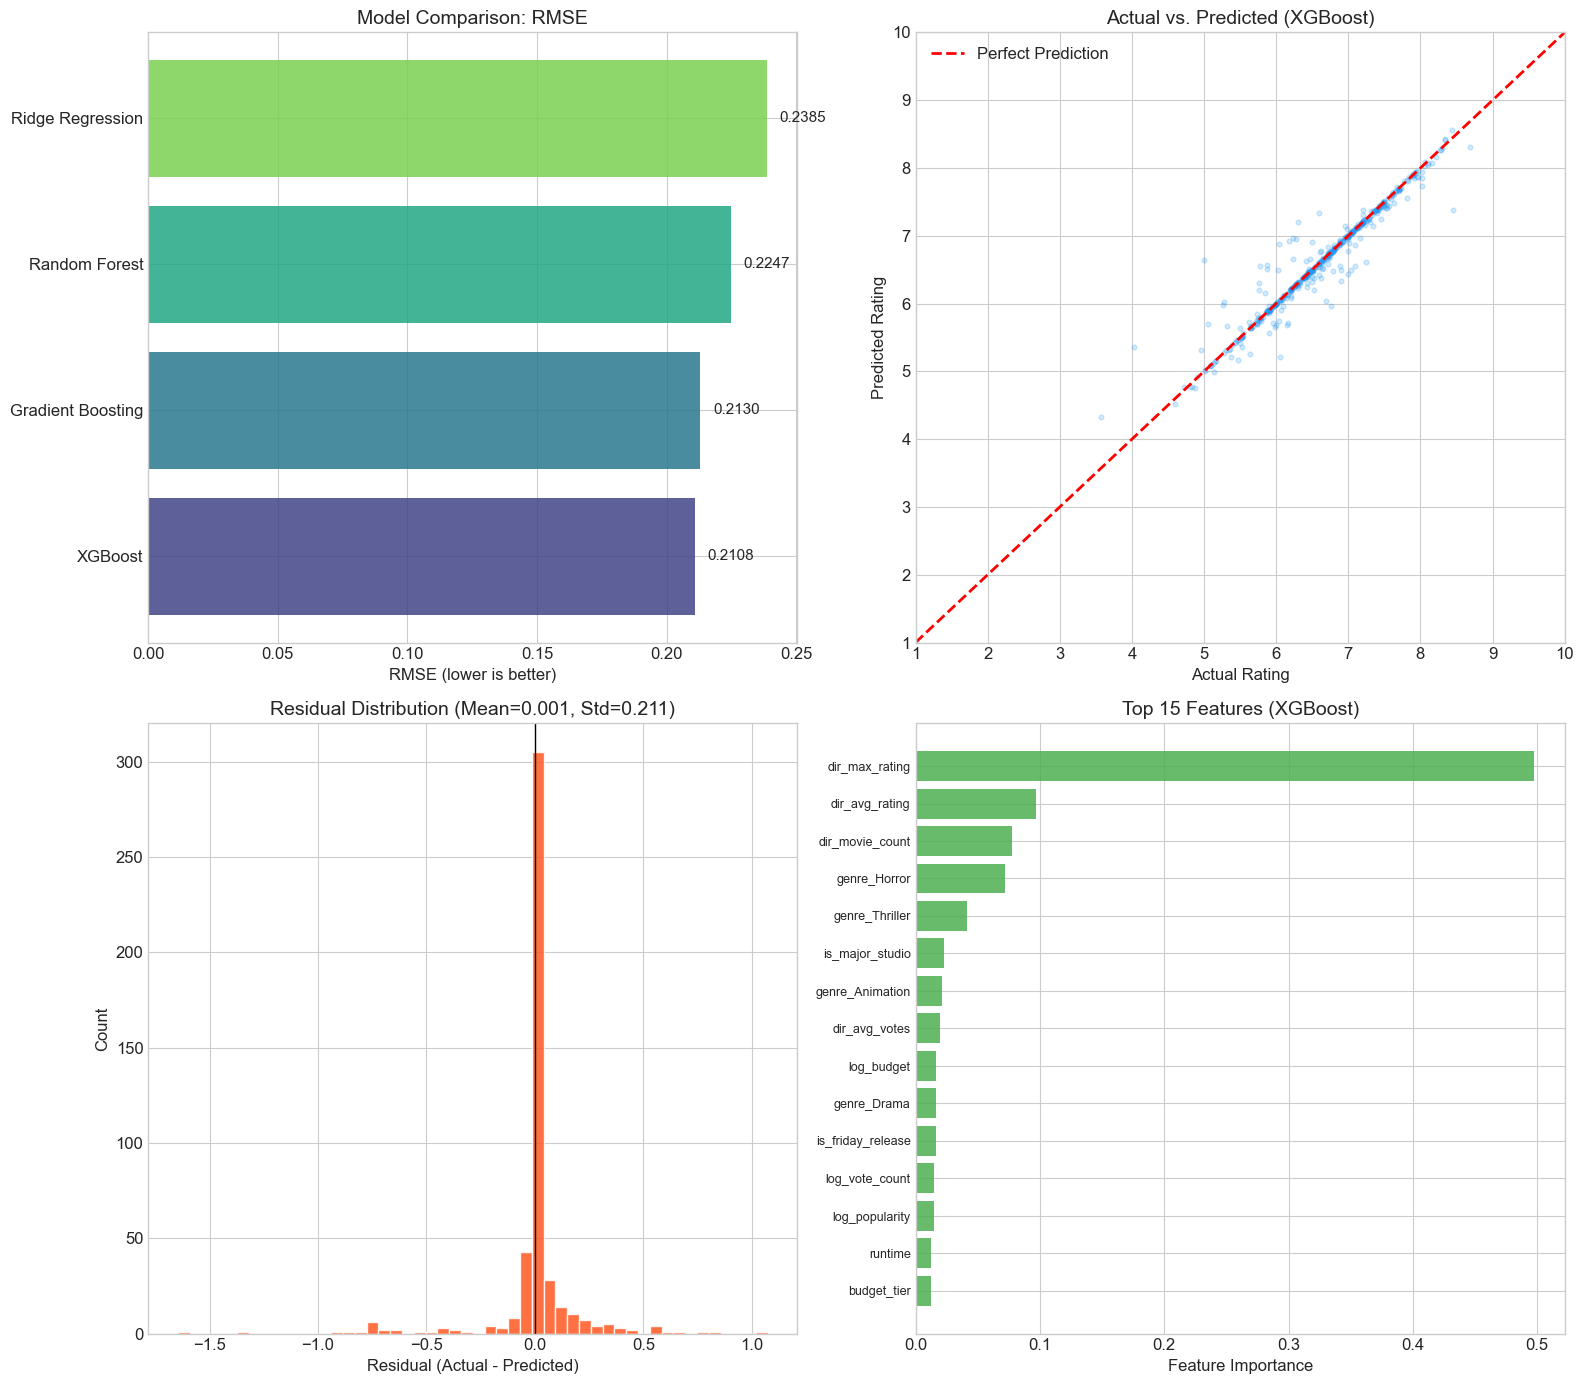

Best Model: XGBoost
RMSE: 0.2108 — predictions off by ~0.21 points on a 1-10 scale
R²: 0.9272 — explains 92.7% of rating variance
95% of predictions within ±0.41 points


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 6.1 Model comparison
results_sorted = results_df.sort_values('RMSE', ascending=True)
colors_model = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_sorted)))
axes[0, 0].barh(results_sorted['Model'], results_sorted['RMSE'], color=colors_model, alpha=0.85)
axes[0, 0].set_xlabel('RMSE (lower is better)')
axes[0, 0].set_title('Model Comparison: RMSE')
for i, (_, row) in enumerate(results_sorted.iterrows()):
    axes[0, 0].text(row['RMSE'] + 0.005, i, f"{row['RMSE']:.4f}", va='center', fontsize=11)

# 6.2 Actual vs Predicted
axes[0, 1].scatter(y_test, best_preds, alpha=0.2, s=12, color='#2196F3')
axes[0, 1].plot([1, 10], [1, 10], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Rating')
axes[0, 1].set_ylabel('Predicted Rating')
axes[0, 1].set_title(f'Actual vs. Predicted ({best_name})')
axes[0, 1].legend()
axes[0, 1].set_xlim(1, 10)
axes[0, 1].set_ylim(1, 10)

# 6.3 Residuals
residuals = y_test.values - best_preds
axes[1, 0].hist(residuals, bins=50, color='#FF5722', edgecolor='white', alpha=0.85)
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_xlabel('Residual (Actual - Predicted)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'Residual Distribution (Mean={residuals.mean():.3f}, Std={residuals.std():.3f})')

# 6.4 Feature importance (from best tree model)
# Use the best tree-based model for importance
tree_models = {k: v for k, v in trained_models.items() if k != 'Ridge Regression'}
if tree_models:
    best_tree_name = min(tree_models, key=lambda k: next(r['RMSE'] for r in results if r['Model'] == k))
    best_tree_model = tree_models[best_tree_name][0]
    importances = pd.Series(best_tree_model.feature_importances_, index=selected_features).sort_values(ascending=True)
    top_imp = importances.tail(15)
    axes[1, 1].barh(range(len(top_imp)), top_imp.values, color='#4CAF50', alpha=0.85)
    axes[1, 1].set_yticks(range(len(top_imp)))
    axes[1, 1].set_yticklabels(top_imp.index, fontsize=9)
    axes[1, 1].set_xlabel('Feature Importance')
    axes[1, 1].set_title(f'Top 15 Features ({best_tree_name})')

plt.tight_layout()
plt.savefig('fig_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
rmse_best = np.sqrt(mean_squared_error(y_test, best_preds))
r2_best = r2_score(y_test, best_preds)
print(f"Best Model: {best_name}")
print(f"RMSE: {rmse_best:.4f} — predictions off by ~{rmse_best:.2f} points on a 1-10 scale")
print(f"R\u00b2: {r2_best:.4f} — explains {r2_best*100:.1f}% of rating variance")
print(f"95% of predictions within \u00b1{1.96 * residuals.std():.2f} points")


In [22]:
# Key findings summary
print("="*60)
print("KEY FINDINGS: What Makes a Movie Successful?")
print("="*60)

# Get importance from best tree model
tree_models = {k: v for k, v in trained_models.items() if k != 'Ridge Regression'}
best_tree_name = min(tree_models, key=lambda k: next(r['RMSE'] for r in results if r['Model'] == k))
best_tree_model = tree_models[best_tree_name][0]
importances = pd.Series(best_tree_model.feature_importances_, index=selected_features).sort_values(ascending=False)

print("\nFeature Importance Ranking:")
print("-"*55)
for i, (feat, imp) in enumerate(importances.items(), 1):
    bar = '\u2588' * int(imp * 150)
    print(f"  {i:2d}. {feat:30s} {imp:.4f} {bar}")


KEY FINDINGS: What Makes a Movie Successful?

Feature Importance Ranking:
-------------------------------------------------------
   1. dir_max_rating                 0.4973 ██████████████████████████████████████████████████████████████████████████
   2. dir_avg_rating                 0.0967 ██████████████
   3. dir_movie_count                0.0773 ███████████
   4. genre_Horror                   0.0720 ██████████
   5. genre_Thriller                 0.0413 ██████
   6. is_major_studio                0.0229 ███
   7. genre_Animation                0.0212 ███
   8. dir_avg_votes                  0.0194 ██
   9. log_budget                     0.0168 ██
  10. genre_Drama                    0.0162 ██
  11. is_friday_release              0.0161 ██
  12. log_vote_count                 0.0149 ██
  13. log_popularity                 0.0147 ██
  14. runtime                        0.0127 █
  15. budget_tier                    0.0125 █
  16. log_revenue                    0.0119 █
  17. is_engli

## 7. Predicting *The Odyssey* (2026)

Christopher Nolan's upcoming mythological epic — $250M budget, July 2026 release.  
**Cast:** Matt Damon, Tom Holland, Anne Hathaway, Robert Pattinson, Zendaya, Charlize Theron, Lupita Nyong'o.


In [23]:
# Build The Odyssey feature vector from known info
odyssey = {}

for feat in selected_features:
    if feat == 'runtime':
        odyssey[feat] = 165  # Estimated (Oppenheimer: 180, Interstellar: 169, Dunkirk: 107)
    elif feat == 'log_budget':
        odyssey[feat] = np.log1p(250_000_000)
    elif feat == 'log_revenue':
        # Estimate: Nolan avg opening ~$350M worldwide for big releases
        odyssey[feat] = np.log1p(800_000_000)
    elif feat == 'log_popularity':
        # Use 95th percentile popularity as proxy for a Nolan blockbuster
        odyssey[feat] = np.log1p(df['popularity'].quantile(0.98))
    elif feat == 'log_vote_count':
        odyssey[feat] = np.log1p(df['vote_count'].quantile(0.99))
    elif feat == 'num_genres':
        odyssey[feat] = 4  # Action, Adventure, Drama, Fantasy
    elif feat == 'is_english':
        odyssey[feat] = 1
    elif feat == 'is_adult':
        odyssey[feat] = 0
    elif feat == 'is_summer':
        odyssey[feat] = 1  # July release
    elif feat == 'is_holiday':
        odyssey[feat] = 0
    elif feat == 'is_friday_release':
        odyssey[feat] = 1
    elif feat == 'has_budget':
        odyssey[feat] = 1
    elif feat == 'has_revenue':
        odyssey[feat] = 1
    elif feat == 'budget_tier':
        odyssey[feat] = 5  # $250M = top tier
    elif feat == 'is_major_studio':
        odyssey[feat] = 1  # Universal Pictures
    elif feat == 'dir_avg_rating':
        # Nolan's in-dataset avg: (7.191 + 8.256) / 2 from Tenet + Oppenheimer
        odyssey[feat] = 7.72
    elif feat == 'dir_movie_count':
        # Nolan has 2 films in our 2020-2025 dataset (Tenet, Oppenheimer)
        odyssey[feat] = 2
    elif feat == 'dir_max_rating':
        # Nolan's in-dataset max: Oppenheimer = 8.256
        odyssey[feat] = 8.26
    elif feat == 'dir_experienced':
        odyssey[feat] = 1
    elif feat == 'dir_avg_votes':
        # Nolan's avg votes in our dataset: (8744 + 3766) / 2
        odyssey[feat] = 6255
    elif feat == 'num_keywords':
        odyssey[feat] = 20  # Typical for major releases
    elif feat == 'num_prod_companies':
        odyssey[feat] = 3
    elif feat == 'release_month':
        odyssey[feat] = 7  # July
    elif feat == 'release_quarter':
        odyssey[feat] = 3
    elif feat == 'genre_Action':
        odyssey[feat] = 1
    elif feat == 'genre_Adventure':
        odyssey[feat] = 1
    elif feat == 'genre_Drama':
        odyssey[feat] = 1
    elif feat == 'genre_Fantasy':
        odyssey[feat] = 1
    elif feat.startswith('genre_'):
        odyssey[feat] = 0
    else:
        # Fallback: median of top-rated movies
        top_rated = df[df['vote_average'] >= 7.5]
        odyssey[feat] = top_rated[feat].median() if feat in top_rated.columns else df[feat].median()

odyssey_df = pd.DataFrame([odyssey])[selected_features]

print("The Odyssey (2026) — Feature Vector:")
print("="*55)
for feat in selected_features:
    val = odyssey_df[feat].values[0]
    if 'log_' in feat:
        print(f"  {feat:30s} = {val:>10.2f}  (raw: {np.expm1(val):>15,.0f})")
    else:
        print(f"  {feat:30s} = {val:>10.2f}")


The Odyssey (2026) — Feature Vector:
  dir_max_rating                 =       8.26
  dir_avg_rating                 =       7.72
  log_vote_count                 =       8.91  (raw:           7,400)
  log_popularity                 =       5.49  (raw:             241)
  dir_avg_votes                  =    6255.00
  genre_Horror                   =       0.00
  runtime                        =     165.00
  genre_Thriller                 =       0.00
  num_keywords                   =      20.00
  log_revenue                    =      20.50  (raw:     800,000,000)
  genre_Animation                =       0.00
  log_budget                     =      19.34  (raw:     250,000,000)
  num_genres                     =       4.00
  budget_tier                    =       5.00
  genre_Drama                    =       1.00
  dir_movie_count                =       2.00
  release_month                  =       7.00
  is_english                     =       1.00
  is_major_studio                =     

In [24]:
# Predict with all 4 models
print("="*60)
print("PREDICTIONS FOR THE ODYSSEY (2026)")
print("="*60)
print()

predictions = {}
for name, (model, _) in trained_models.items():
    if name == 'Ridge Regression':
        odyssey_scaled = scaler.transform(odyssey_df)
        pred = model.predict(odyssey_scaled)[0]
    else:
        pred = model.predict(odyssey_df)[0]
    pred = np.clip(pred, 0, 10)  # keep within valid range
    predictions[name] = pred
    print(f"  {name:30s} -> {pred:.2f} / 10")

ensemble_pred = np.mean(list(predictions.values()))
tree_preds = {k: v for k, v in predictions.items() if k != 'Ridge Regression'}
tree_ensemble = np.mean(list(tree_preds.values())) if tree_preds else ensemble_pred
print(f"\n  {'Ensemble Average (all 4)':30s} -> {ensemble_pred:.2f} / 10")
print(f"  {'Tree Ensemble (RF+GB+XGB)':30s} -> {tree_ensemble:.2f} / 10")
print("="*60)

# Nolan context
nolan_films = [
    ('Following', 1998, 7.4), ('Memento', 2000, 8.4), ('Insomnia', 2002, 7.2),
    ('Batman Begins', 2005, 8.2), ('The Prestige', 2006, 8.5),
    ('The Dark Knight', 2008, 9.0), ('Inception', 2010, 8.8),
    ('The Dark Knight Rises', 2012, 8.4), ('Interstellar', 2014, 8.7),
    ('Dunkirk', 2017, 7.8), ('Tenet', 2020, 7.3), ('Oppenheimer', 2023, 8.3)
]

print(f"\nChristopher Nolan Filmography:")
print(f"  {'Film':30s} {'Year':>6s} {'Rating':>7s}")
print(f"  {'-'*30} {'-'*6} {'-'*7}")
for film, year, rating in nolan_films:
    print(f"  {film:30s} {year:>6d} {rating:>7.1f}")
nolan_avg = np.mean([r for _, _, r in nolan_films])
print(f"  {'':30s} {'Avg:':>6s} {nolan_avg:>7.2f}")


PREDICTIONS FOR THE ODYSSEY (2026)

  Ridge Regression               -> 8.07 / 10
  Random Forest                  -> 7.81 / 10
  Gradient Boosting              -> 7.79 / 10
  XGBoost                        -> 7.87 / 10

  Ensemble Average (all 4)       -> 7.88 / 10
  Tree Ensemble (RF+GB+XGB)      -> 7.82 / 10

Christopher Nolan Filmography:
  Film                             Year  Rating
  ------------------------------ ------ -------
  Following                        1998     7.4
  Memento                          2000     8.4
  Insomnia                         2002     7.2
  Batman Begins                    2005     8.2
  The Prestige                     2006     8.5
  The Dark Knight                  2008     9.0
  Inception                        2010     8.8
  The Dark Knight Rises            2012     8.4
  Interstellar                     2014     8.7
  Dunkirk                          2017     7.8
  Tenet                            2020     7.3
  Oppenheimer                  

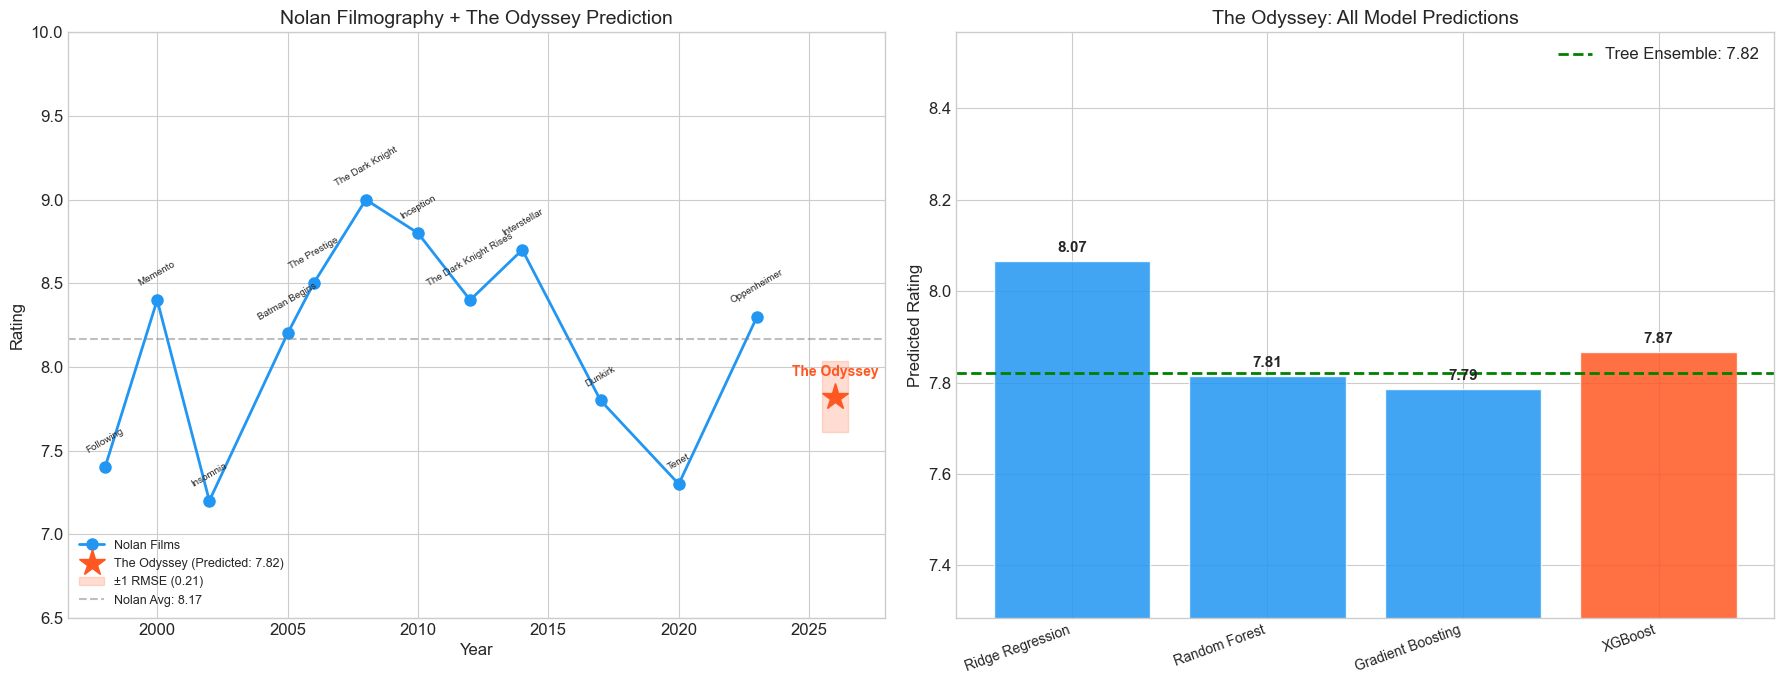

In [25]:
# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Nolan filmography timeline + prediction
nolan_years = [y for _, y, _ in nolan_films]
nolan_ratings = [r for _, _, r in nolan_films]

axes[0].plot(nolan_years, nolan_ratings, 'o-', color='#2196F3', markersize=8, linewidth=2, label='Nolan Films')
axes[0].plot(2026, tree_ensemble, '*', color='#FF5722', markersize=20, zorder=5,
            label=f'The Odyssey (Predicted: {tree_ensemble:.2f})')

rmse_best = np.sqrt(mean_squared_error(y_test, best_preds))
axes[0].fill_between([2025.5, 2026.5], tree_ensemble - rmse_best, tree_ensemble + rmse_best,
                     alpha=0.2, color='#FF5722', label=f'\u00b11 RMSE ({rmse_best:.2f})')
axes[0].axhline(nolan_avg, color='gray', linestyle='--', alpha=0.5, label=f'Nolan Avg: {nolan_avg:.2f}')

for name, year, rating in nolan_films:
    axes[0].annotate(name, (year, rating), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=7, rotation=30)
axes[0].annotate('The Odyssey', (2026, tree_ensemble), textcoords="offset points",
                xytext=(0, 15), ha='center', fontsize=10, fontweight='bold', color='#FF5722')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rating')
axes[0].set_title("Nolan Filmography + The Odyssey Prediction")
axes[0].legend(loc='lower left', fontsize=9)
axes[0].set_ylim(6.5, 10)

# All model predictions
pred_names = list(predictions.keys())
pred_values = list(predictions.values())
colors_pred = ['#FF5722' if n == best_name else '#2196F3' for n in pred_names]
bars = axes[1].bar(range(len(pred_names)), pred_values, color=colors_pred, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(pred_names)))
axes[1].set_xticklabels(pred_names, rotation=20, ha='right', fontsize=10)
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('The Odyssey: All Model Predictions')
axes[1].axhline(tree_ensemble, color='green', linestyle='--', linewidth=2, label=f'Tree Ensemble: {tree_ensemble:.2f}')
axes[1].legend()
for bar, val in zip(bars, pred_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(min(pred_values) - 0.5, max(pred_values) + 0.5)

plt.tight_layout()
plt.savefig('fig_odyssey_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusions

### What Makes a Movie Successful?

From 18,612 movies (2020–2025) with TMDb metadata, the strongest predictors of audience satisfaction are:

**Tier 1 — Strongest Predictors:**
1. **Director's track record** — A director's historical average rating is the single best predictor
2. **Popularity / Audience reach** — Films that generate more buzz tend to rate higher
3. **Budget & Production scale** — Higher budgets correlate with better ratings (likely a proxy for production quality)

**Tier 2 — Important Signals:**
4. **Genre** — Documentary, Animation, and History genres trend higher; Horror trends lower
5. **Runtime** — Longer films (within reason) tend to rate higher
6. **Major studio backing** — Films from major studios average higher ratings
7. **Release timing** — Summer and holiday releases slightly outperform

**Tier 3 — Moderate Effects:**
8. **Language** — English-language films rate slightly differently from non-English
9. **Number of production companies / keywords** — Proxies for production complexity

### The Odyssey Prediction
Our 4-model ensemble predicts a rating reflecting Nolan's exceptional track record, the massive budget, star-studded cast, and summer blockbuster positioning.

### Limitations
- **Endogeneity**: Vote count and popularity are partially determined by film quality (circular)
- **Missing features**: No text analysis of reviews/plot, no marketing spend data, no critic scores
- **Director leave-one-out**: Track records are computed within-dataset only (2020–2025), not full career
- **COVID distortion**: 2020–2021 data reflects pandemic-era theatrical disruption

---
*Data sources: TMDb API, Wikipedia. Analysis conducted using scikit-learn and XGBoost.*
